# Railway Desert Analysis

This study is for railway access at the district level. The idea is to combine station, schedule, and train records into a single railway table, and then map that railway information to Census 2011 districts, then add demographic, Shrug, and economic context for regression model.

In [1]:
import json
from pathlib import Path
import re
from difflib import get_close_matches

import pandas as pd
import numpy as np
import geopandas as gpd
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.anova import anova_lm
from scipy.stats import jarque_bera, shapiro, skew, kurtosis
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns

# Project visual palette: cold = low access, warm = middle, hot = high access.
cold_warm_hot_cmap = LinearSegmentedColormap.from_list(
    'cold_warm_hot',
    ['#2563eb', '#facc15', '#dc2626']
)
cold_color = '#2563eb'
warm_color = '#f59e0b'
hot_color = '#dc2626'


## 1. Data loading and preparation

In [3]:
DATA_DIR = Path('../common_dataset/data')

# Railway
with open(DATA_DIR / 'rail' / 'stations.json', 'r', encoding='utf-8') as f:
    stations_geojson = json.load(f)
with open(DATA_DIR / 'rail' / 'trains.json', 'r', encoding='utf-8') as f:
    trains_geojson = json.load(f)

station_rows = []
for feat in stations_geojson['features']:
    props = feat.get('properties', {})
    geom = feat.get('geometry') or {}
    coords = geom.get('coordinates') if geom.get('type') == 'Point' else None
    lon = coords[0] if isinstance(coords, (list, tuple)) and len(coords) > 1 else np.nan
    lat = coords[1] if isinstance(coords, (list, tuple)) and len(coords) > 1 else np.nan
    station_rows.append({
        'code': props.get('code'),
        'name': props.get('name'),
        'state': props.get('state'),
        'zone': props.get('zone'),
        'address': props.get('address'),
        'lon': lon,
        'lat': lat,
    })

stations = pd.DataFrame(station_rows)
schedules = pd.read_json(DATA_DIR / 'rail' / 'schedules.json')

train_rows = []
for feat in trains_geojson['features']:
    props = feat.get('properties', {})
    train_rows.append({
        'train_number': str(props.get('number')),
        'train_name_master': props.get('name'),
        'train_type': props.get('type'),
        'train_zone': props.get('zone'),
        'from_station_code': props.get('from_station_code'),
        'from_station_name': props.get('from_station_name'),
        'to_station_code': props.get('to_station_code'),
        'to_station_name': props.get('to_station_name'),
        'distance': props.get('distance'),
        'duration_h': props.get('duration_h'),
        'duration_m': props.get('duration_m'),
        'first_ac': props.get('first_ac'),
        'second_ac': props.get('second_ac'),
        'third_ac': props.get('third_ac'),
        'sleeper': props.get('sleeper'),
        'chair_car': props.get('chair_car'),
        'first_class': props.get('first_class'),
    })

trains = pd.DataFrame(train_rows)

rail_combined = schedules.copy()
rail_combined['train_number'] = rail_combined['train_number'].astype(str)
rail_combined = rail_combined.merge(trains, on='train_number', how='left')
rail_combined = rail_combined.merge(
    stations.rename(columns={
        'code': 'station_code',
        'name': 'station_name_master',
        'state': 'station_state',
        'zone': 'station_zone',
        'address': 'station_address',
    }),
    on='station_code',
    how='left'
)

# Economy data
econ = pd.read_csv(DATA_DIR/'economy'/ 'Economy_Productivity_SD_India.csv')
sector_econ = pd.read_csv(DATA_DIR/'economy'/'District-Wise Sectoral Analysis of Indian States.csv')

# Demographics data
demo = pd.read_csv(DATA_DIR/'demographics'/'demographics.csv', encoding='iso-8859-1')
demo = demo.rename(columns={'ÿCountry': 'Country'})

# SHRuG Census 2011 district and subdistrict levels
shrug_dist = pd.read_csv(
    DATA_DIR/'shrug'/'secc_rural_pc11dist.csv',
    dtype={'pc11_state_id': str, 'pc11_district_id': str}
)
shrug_subdist = pd.read_csv(
    DATA_DIR/'shrug'/'secc_rural_pc11subdist.csv',
    dtype={'pc11_state_id': str, 'pc11_district_id': str, 'pc11_subdistrict_id': str}
)

# Census 2011 district polygons
districts = gpd.read_file(DATA_DIR/'demographics'/'Census_2011'/'2011_Dist.shp')[
    ['DISTRICT', 'ST_NM', 'ST_CEN_CD', 'DT_CEN_CD', 'geometry']
]

## 2. Data inspection

In [4]:
for name, d in [
    ('stations', stations),
    ('trains', trains),
    ('schedules', schedules),
    ('rail_combined', rail_combined),
    ('economy', econ),
    ('sector_economy', sector_econ),
    ('demographics', demo),
    ('shrug_district', shrug_dist),
    ('shrug_subdistrict', shrug_subdist),
    ('census_districts', districts),
]:
    print(f"\n{name}: shape={d.shape}")
    print(d.head(3))





stations: shape=(8990, 7)
      code     name      state  zone                       address        lon  \
0     BDHL   Badhal  Rajasthan   NWR  Kishangarh Renwal, Rajasthan  75.451645   
1  XX-BECE  XX-BECE       None  None                          None        NaN   
2  XX-BSPY  XX-BSPY       None  None                          None        NaN   

         lat  
0  27.252059  
1        NaN  
2        NaN  

trains: shape=(5208, 17)
  train_number            train_name_master train_type train_zone  \
0        04601  Jammu Tawi Udhampur Special       DEMU         NR   
1        04602       UDHAMPUR JAMMUTAWI DMU       DEMU         NR   
2        04603             JAT UDAHMPUR DMU       DEMU         NR   

  from_station_code from_station_name to_station_code to_station_name  \
0               JAT        JAMMU TAWI             UHP        UDHAMPUR   
1               UHP          UDHAMPUR             JAT      JAMMU TAWI   
2               JAT        JAMMU TAWI             UHP        UDHAM

## 3. Standardization

I found that some district and state names were not consistent across multiple sources. So, I needed to create a standarized version so that district name could be consistent.


In [4]:
def rename_text(x):
    x = str(x).strip().lower()
    x = x.replace('&', 'and')
    x = re.sub(r'\s+', ' ', x)
    return x

state_map = {
    'delhi nct': 'nct of delhi',
    'delhi': 'nct of delhi',
    'orissa': 'odisha',
    'uttaranchal': 'uttarakhand',
    'andaman and nicobar': 'andaman and nicobar island',
    'dadra and nagar haveli': 'dadara and nagar havelli',
    'daman and diu': 'daman and diu',
    'jammu and kashmir': 'jammu and kashmir',
    'jammu & kashmir': 'jammu and kashmir',
    'arunachal pradesh': 'arunanchal pradesh',
}

district_map = {
    'ahmadabad': 'ahmedabad',
    'ahmadnagar': 'ahmednagar',
    'anantnag (kashmir south)': 'anantnag',
    'bangalore rural': 'bangalore rural',
    'bangalore urban': 'bangalore',
    'bengaluru': 'bangalore',
    'anugul': 'angul',
    'baramulla': 'baramula',
    'budgam': 'badgam',
    'boudh': 'bauda',
    'dhubri ': 'dhubri',
    'hardwar': 'haridwar',
    'hugli': 'hooghly',
    'panchmahal': 'panch mahals',
    'purbi singhbhum': 'purbi singhbhum',
    'pashchimi singhbhum': 'pashchimi singhbhum',
    'sant ravidas nagar': 'sant ravi das nagar(bhadohi)',
    'ysr': 'y.s.r.',
}

# rename census district keys
districts['district_norm'] = districts['DISTRICT'].apply(rename_text).replace(district_map)
districts['state_norm'] = districts['ST_NM'].apply(rename_text).replace(state_map)
districts['district_key'] = districts['district_norm'] + '|' + districts['state_norm']
districts['state_census_code'] = pd.to_numeric(districts['ST_CEN_CD'], errors='coerce').astype('Int64')
districts['district_census_code'] = pd.to_numeric(districts['DT_CEN_CD'], errors='coerce').astype('Int64')

# rename shrug Census district identifiers
shrug_dist['state_census_code'] = pd.to_numeric(shrug_dist['pc11_state_id'], errors='coerce').astype('Int64')
shrug_dist['district_census_code'] = pd.to_numeric(shrug_dist['pc11_district_id'], errors='coerce').astype('Int64')
shrug_subdist['state_census_code'] = pd.to_numeric(shrug_subdist['pc11_state_id'], errors='coerce').astype('Int64')
shrug_subdist['district_census_code'] = pd.to_numeric(shrug_subdist['pc11_district_id'], errors='coerce').astype('Int64')
shrug_subdist['subdistrict_census_code'] = pd.to_numeric(shrug_subdist['pc11_subdistrict_id'], errors='coerce').astype('Int64')
shrug_subdist['subdistrict_key'] = (
    shrug_subdist['pc11_state_id'].astype(str) + '|' +
    shrug_subdist['pc11_district_id'].astype(str) + '|' +
    shrug_subdist['pc11_subdistrict_id'].astype(str)
)

# rename railway
station_cols = ['code', 'name', 'state', 'zone', 'address', 'lon', 'lat']
stations = stations[station_cols].copy()
stations['state_norm'] = stations['state'].apply(rename_text).replace(state_map)
stations = stations.dropna(subset=['lon', 'lat'])

rail_combined['station_state_norm'] = rail_combined['station_state'].apply(rename_text).replace(state_map)
rail_combined = rail_combined.dropna(subset=['station_code', 'lon', 'lat']).copy()

# rename demographics
demo['district_norm'] = demo['District'].apply(rename_text).replace(district_map)
demo['state_norm'] = demo['State'].apply(rename_text).replace(state_map)
demo['district_key_raw'] = demo['district_norm'] + '|' + demo['state_norm']

# rename economy city names
econ['city_norm'] = econ['City'].apply(rename_text)
latest_year = econ['Year'].max()
econ = econ[econ['Year'] == latest_year].copy()
econ = econ.fillna(econ.mean(numeric_only=True))

# rename district-wise sectoral economy keys
sector_econ['district_norm'] = sector_econ['Dist Name'].apply(rename_text).replace(district_map)
sector_econ['state_norm'] = sector_econ['State Name'].apply(rename_text).replace(state_map)
sector_econ['district_key_raw'] = sector_econ['district_norm'] + '|' + sector_econ['state_norm']
sector_econ['sector_year'] = sector_econ['Year'].astype(str).str.extract(r'(\d{4})')[0].astype(float)

demo = demo.fillna(demo.mean(numeric_only=True))




## 4. Mapping

Use rail_combined with station longitude and latitude to assign each scheduled railway stop to a Census district.


In [5]:
rail_stop_gdf = gpd.GeoDataFrame(
    rail_combined.copy(),
    geometry=gpd.points_from_xy(rail_combined['lon'], rail_combined['lat']),
    crs='EPSG:4326',
)

# district assignment for stops that lie within the polygon boundary
rail_within = gpd.sjoin(
    rail_stop_gdf,
    districts[['district_key', 'district_norm', 
    'state_norm', 'geometry']],
    how='left',
    predicate='within',
)

# nearest district for stops that are outside the polygon
outside = rail_within[rail_within['district_key'].isna()].copy()
inside = rail_within[rail_within['district_key'].notna()].copy()

if len(outside) > 0:
    drop_cols = [c for c in ['index_right', 'district_key', 
    'district_norm', 'state_norm'] if c in outside.columns]
    outside_clean = outside.drop(columns=drop_cols)
    outside_projected = outside_clean.to_crs(epsg=3857)

    districts_projected = districts[['district_key', 'district_norm', 
    'state_norm', 'geometry']].to_crs(epsg=3857)
    nearest_proj = gpd.sjoin_nearest(
        outside_projected,
        districts_projected,
        how='left',
        distance_col='nearest_dist_m',
    )
    nearest = nearest_proj.to_crs(epsg=4326)
    rail_district = pd.concat([inside, nearest], ignore_index=True)
else:
    rail_district = inside.copy()

rail_district = rail_district[rail_district['district_key'].notna()].copy()

state_col = 'state_norm_right' if 'state_norm_right' in rail_district.columns else 'state_norm'
district_col = 'district_norm_right' if 'district_norm_right' in rail_district.columns else 'district_norm'

rail_district = rail_district.rename(columns={
    district_col: 'district_norm_joined',
    state_col: 'state_norm_joined'
})

# So, the dataset is at station level and needs to be aggregated at the district level
rail_aggreg = (
    rail_district.groupby(['district_key', 'district_norm_joined', 'state_norm_joined'])
    .agg(
        station_count=('station_code', 'nunique'),
        weekly_trains=('train_number', 'nunique'),
        stop_events=('id', 'count'),
        train_type_count=('train_type', 'nunique'),
        avg_train_distance=('distance', 'mean'),
        avg_duration_h=('duration_h', 'mean'),
        ac_train_share=('third_ac', 'mean'),
        sleeper_train_share=('sleeper', 'mean')
    )
    .reset_index()
    .rename(columns={
        'district_norm_joined': 'district_norm',
        'state_norm_joined': 'state_norm'
    })
)

print('Combined railway dataset shape:', rail_combined.shape)
print('Rail districts after assignment:', rail_aggreg.shape[0])


Combined railway dataset shape: (414420, 31)
Rail districts after assignment: 514


## 5. Combine datasets

`data_combi_1` is the district-level df. contains census districts and left joins the railway district summary, demographics, shrug indicators, and the existing city economy file.

`data_combi_2` is then created by left joining `data_combi_1` with all disticts and economic dataset.


In [6]:
# Demographics aggregated
demo_agg = (
    demo.groupby(['district_key_raw', 'district_norm', 'state_norm'])
    .agg(
        geo_point_count=('Number of Records', 'sum'),
        avg_latitude=('Latitude', 'mean'),
        avg_longitude=('Longitude', 'mean')
    )
    .reset_index()
)

census_keys = set(districts['district_key'])
census_by_state = (
    districts[['state_norm', 'district_norm']]
    .drop_duplicates()
    .groupby('state_norm')['district_norm']
    .apply(list)
    .to_dict()
)

def map_to_census_key(district_norm, state_norm):
    key = f'{district_norm}|{state_norm}'
    if key in census_keys:
        return key
    candidates = census_by_state.get(state_norm, [])
    if not candidates:
        return np.nan
    best = get_close_matches(district_norm, candidates, n=1, cutoff=0.82)
    if best:
        return f'{best[0]}|{state_norm}'
    return np.nan

demo_agg['district_key'] = demo_agg.apply(
    lambda r: map_to_census_key(r['district_norm'], r['state_norm']),
    axis=1
)

demo_agg = (
    demo_agg[demo_agg['district_key'].notna()]
    .groupby('district_key')
    .agg(
        geo_point_count=('geo_point_count', 'sum'),
        avg_latitude=('avg_latitude', 'mean'),
        avg_longitude=('avg_longitude', 'mean')
    )
    .reset_index()
)

# shrug rural socioeconomic indicators at district level
shrug_feature_cols = [
    'secc_hh', 'tot_p', 'sc_share', 'st_share',
    'ed_prim_share', 'ed_sec_share', 'ed_grad_share',
    'land_own_share', 'inc_5k_plus_share', 'inc_10k_plus_share',
    'salary_any_share', 'salary_gov_share', 'salary_priv_share',
    'ag_inc_hh', 'veh_two_three_share', 'veh_four_share',
    'wall_mat_solid_share', 'roof_mat_solid_share',
    'num_room_mean', 'irr_share1', 'irr_share2'
]
shrug_feature_cols = [c for c in shrug_feature_cols if c in shrug_dist.columns]

shrug_agg = shrug_dist[['state_census_code', 'district_census_code'] + shrug_feature_cols].copy()
for col in shrug_feature_cols:
    shrug_agg[col] = pd.to_numeric(shrug_agg[col], errors='coerce')

shrug_agg = (
    shrug_agg.groupby(['state_census_code', 'district_census_code'], dropna=False)
    .mean(numeric_only=True)
    .reset_index()
    .rename(columns={c: f'shrug_{c}' for c in shrug_feature_cols})
)

# city to district mapping
city_to_district_state = {
    'agra': ('agra', 'uttar pradesh'),
    'ahmedabad': ('ahmedabad', 'gujarat'),
    'allahabad': ('allahabad', 'uttar pradesh'),
    'amritsar': ('amritsar', 'punjab'),
    'aurangabad': ('aurangabad', 'maharashtra'),
    'bengaluru': ('bangalore', 'karnataka'),
    'bhopal': ('bhopal', 'madhya pradesh'),
    'chennai': ('chennai', 'tamil nadu'),
    'delhi': ('new delhi', 'nct of delhi'),
    'dhanbad': ('dhanbad', 'jharkhand'),
    'faridabad': ('faridabad', 'haryana'),
    'hyderabad': ('hyderabad', 'andhra pradesh'),
    'indore': ('indore', 'madhya pradesh'),
    'jaipur': ('jaipur', 'rajasthan'),
    'kanpur': ('kanpur nagar', 'uttar pradesh'),
    'kolkata': ('kolkata', 'west bengal'),
    'lucknow': ('lucknow', 'uttar pradesh'),
    'ludhiana': ('ludhiana', 'punjab'),
    'meerut': ('meerut', 'uttar pradesh'),
    'mumbai': ('mumbai suburban', 'maharashtra'),
    'nagpur': ('nagpur', 'maharashtra'),
    'nashik': ('nashik', 'maharashtra'),
    'patna': ('patna', 'bihar'),
    'pune': ('pune', 'maharashtra'),
    'rajkot': ('rajkot', 'gujarat'),
    'ranchi': ('ranchi', 'jharkhand'),
    'srinagar': ('srinagar', 'jammu and kashmir'),
    'surat': ('surat', 'gujarat'),
    'vadodara': ('vadodara', 'gujarat'),
    'varanasi': ('varanasi', 'uttar pradesh'),
}

econ['district_norm'] = econ['city_norm'].map(lambda c: city_to_district_state.get(c, (np.nan, np.nan))[0])
econ['state_norm'] = econ['city_norm'].map(lambda c: city_to_district_state.get(c, (np.nan, np.nan))[1])
econ['district_key'] = econ['district_norm'] + '|' + econ['state_norm']

econ_agg = (
    econ[econ['district_key'].notna()]
    .groupby('district_key')
    .mean(numeric_only=True)
    .reset_index()
)

sector_numeric_cols = [
    c for c in sector_econ.select_dtypes(include=[np.number]).columns
    if c not in ['Dist Code', 'State Code']
]
sector_panel = sector_econ[['district_key_raw', 'Year'] + sector_numeric_cols].copy()
sector_panel = sector_panel[sector_panel['district_key_raw'].notna()].rename(
    columns={'district_key_raw': 'district_key', 'Year': 'sector_year_label'}
)
sector_col_map = {
    c: 'sector_' + re.sub(r'[^0-9a-zA-Z]+', '_', c).strip('_').lower()
    for c in sector_numeric_cols
}
sector_panel = sector_panel.rename(columns=sector_col_map)

base_df = districts[['district_key', 'district_norm',
 'state_norm', 'state_census_code', 'district_census_code', 'geometry']].drop_duplicates().copy()
base_proj = base_df.to_crs(epsg=3857)
centroids_proj = base_proj.geometry.centroid
centroids = gpd.GeoSeries(centroids_proj, crs='EPSG:3857').to_crs(epsg=4326)
base_df['centroid_lat'] = centroids.y.values
base_df['centroid_lon'] = centroids.x.values
base_df = base_df.drop(columns=['geometry'])

# Merge all sources into 1
data_combi_1 = base_df.merge(rail_aggreg, 
on=['district_key', 'district_norm', 'state_norm'], 
                             how='left')
data_combi_1 = data_combi_1.merge(demo_agg, on='district_key', how='left')
data_combi_1 = data_combi_1.merge(shrug_agg, on=['state_census_code', 'district_census_code'], how='left')
data_combi_1 = data_combi_1.merge(econ_agg, on='district_key', how='left')

# left join data_combi_1 with the district data
data_combi_2 = data_combi_1.merge(sector_panel, on='district_key', how='left')
df = data_combi_2.copy()

# Setting zero for districts with no assigned stops in the combined railway dataset.
for col in ['station_count', 'weekly_trains', 'stop_events', 'train_type_count']:
    if col in df.columns:
        df[col] = df[col].fillna(0)

df['avg_latitude'] = df['avg_latitude'].fillna(df['centroid_lat'])
df['avg_longitude'] = df['avg_longitude'].fillna(df['centroid_lon'])
df['geo_point_count'] = df['geo_point_count'].fillna(df['geo_point_count'].median())

df['shrug_available'] = df['shrug_tot_p'].notna().astype(int) if 'shrug_tot_p' in df.columns else 0
df['econ_available'] = df['district_key'].isin(econ_agg['district_key']).astype(int)
df['sector_econ_available'] = df['district_key'].isin(sector_panel['district_key']).astype(int)

df['district'] = df['district_norm']
df['state'] = df['state_norm']

for col in df.select_dtypes(include=[np.number]).columns:
    df[col] = df[col].fillna(df[col].median())

df = df.replace([np.inf, -np.inf], np.nan)
for col in df.select_dtypes(include=[np.number]).columns:
    df[col] = df[col].fillna(0 if df[col].isna().all() else df[col].median())
print('Remaining NA values in df:', int(df.isna().sum().sum()))

data_combi_2 = df.copy()

print('Raw sectoral economy rows:', sector_econ.shape[0])
print('Sectoral economy panel rows after key cleanup:', sector_panel.shape[0])
print('data_combi_1 shape:', data_combi_1.shape)
print('data_combi_2 shape:', data_combi_2.shape)
print('Merged district-year shape used for MLR:', df.shape)
print('Districts included:', df['district_key'].nunique())
print('Districts with nonzero rail stations:', int((df['station_count'] > 0).sum()))
print('Districts with shrug coverage:', int(df['shrug_available'].sum()))
print('shrug subdistrict observations available:', shrug_subdist['subdistrict_key'].nunique())
print('Districts with city economy coverage:', int(df['econ_available'].sum()))
print('Districts with sectoral economy coverage:', int(df['sector_econ_available'].sum()))





Remaining NA values in df: 414
Raw sectoral economy rows: 2149
Sectoral economy panel rows after key cleanup: 2149
data_combi_1 shape: (641, 47)
data_combi_2 shape: (2003, 69)
Merged district-year shape used for MLR: (2003, 69)
Districts included: 641
Districts with nonzero rail stations: 1816
Districts with shrug coverage: 22
shrug subdistrict observations available: 5804
Districts with city economy coverage: 156
Districts with sectoral economy coverage: 1589


## 5A. Checking Combined Schema

This cell prints the shape and column list of the merged table. It is a quick checkpoint before feature engineering, useful for confirming that the expected railway, demographic, SHRuG, and sectoral economy fields are present.


In [7]:
# Combined dataset overview (run after df is created)
print(f'Combined dataset shape: {df.shape}')
print('\nCombined dataset columns:')
for i, col in enumerate(df.columns, 1):
    print(f'{i}. {col}')


Combined dataset shape: (2003, 69)

Combined dataset columns:
1. district_key
2. district_norm
3. state_norm
4. state_census_code
5. district_census_code
6. centroid_lat
7. centroid_lon
8. station_count
9. weekly_trains
10. stop_events
11. train_type_count
12. avg_train_distance
13. avg_duration_h
14. ac_train_share
15. sleeper_train_share
16. geo_point_count
17. avg_latitude
18. avg_longitude
19. shrug_secc_hh
20. shrug_tot_p
21. shrug_sc_share
22. shrug_st_share
23. shrug_ed_prim_share
24. shrug_ed_sec_share
25. shrug_ed_grad_share
26. shrug_land_own_share
27. shrug_inc_5k_plus_share
28. shrug_inc_10k_plus_share
29. shrug_salary_any_share
30. shrug_salary_gov_share
31. shrug_salary_priv_share
32. shrug_ag_inc_hh
33. shrug_veh_two_three_share
34. shrug_veh_four_share
35. shrug_wall_mat_solid_share
36. shrug_roof_mat_solid_share
37. shrug_num_room_mean
38. shrug_irr_share1
39. shrug_irr_share2
40. Year
41. R&D Expenditure (% of GDP)
42. Patents per 100,000 Inhabitants
43. Unemployment 

## 6. Create Rail Access Features and the Station Target

Here, I would like to see what social, economic, industrial, railway service, and railway spatial access predictors contribute to the number of train stations in a district.


In [8]:
# Derived rail access features
df['station_per_1000_pts'] = 1000 * df['station_count'] / df['geo_point_count'].replace(0, np.nan)
df['train_per_1000_pts'] = 1000 * df['weekly_trains'] / df['geo_point_count'].replace(0, np.nan)
df['stop_per_station'] = df['stop_events'] / df['station_count'].replace(0, np.nan)

# Distance to nearest major hub.
df['major_hub_flag'] = df['econ_available'].fillna(0).astype(int)

district_points = gpd.GeoDataFrame(
    df[['district_key', 'centroid_lon', 'centroid_lat', 'major_hub_flag']].copy(),
    geometry=gpd.points_from_xy(df['centroid_lon'], df['centroid_lat']),
    crs='EPSG:4326'
).to_crs(epsg=3857)

hub_points = district_points[district_points['major_hub_flag'] == 1].copy()

if len(hub_points) > 1:
    nearest_hub_distances = []
    nearest_hub_keys = []

    for _, row in district_points.iterrows():
        candidate_hubs = hub_points.copy()

        # If the district is itself a major hub, measure distance to the next nearest hub.
        if row['major_hub_flag'] == 1:
            candidate_hubs = candidate_hubs[candidate_hubs['district_key'] != row['district_key']]

        distances_m = candidate_hubs.geometry.distance(row.geometry)
        nearest_idx = distances_m.idxmin()
        nearest_hub_distances.append(float(distances_m.loc[nearest_idx]) / 1000)
        nearest_hub_keys.append(candidate_hubs.loc[nearest_idx, 'district_key'])

    df['distance_to_nearest_major_hub_km'] = nearest_hub_distances
    df['nearest_major_hub_key'] = nearest_hub_keys
else:
    df['distance_to_nearest_major_hub_km'] = np.nan
    df['nearest_major_hub_key'] = np.nan

df['distance_to_nearest_major_hub_log'] = np.log1p(df['distance_to_nearest_major_hub_km'])

df['rail_density'] = df['station_count'] / df['geo_point_count'].replace(0, np.nan)
df['rail_density_log'] = np.log1p(df['station_per_1000_pts'])
df['service_intensity_log'] = np.log1p(df['train_per_1000_pts'])
df['access_potential_log'] = np.log1p(0.5 * df['station_per_1000_pts'] + 0.5 * df['train_per_1000_pts'])

derived_cols = [
    'station_per_1000_pts', 'train_per_1000_pts', 'stop_per_station',
    'major_hub_flag', 'distance_to_nearest_major_hub_km', 'distance_to_nearest_major_hub_log',
    'rail_density', 'rail_density_log', 'service_intensity_log', 'access_potential_log'
]
for col in derived_cols:
    df[col] = df[col].replace([np.inf, -np.inf], np.nan).fillna(0)

df = df.replace([np.inf, -np.inf], np.nan)
for col in df.select_dtypes(include=[np.number]).columns:
    df[col] = df[col].fillna(0 if df[col].isna().all() else df[col].median())
data_combi_2 = df.copy()

print('Major hub districts:', int(df['major_hub_flag'].sum()))
print('Distance-to-hub summary, km:')
print(df['distance_to_nearest_major_hub_km'].describe())
print('data_combi_2 final shape used for MLR:', data_combi_2.shape)


Major hub districts: 156
Distance-to-hub summary, km:
count    2003.000000
mean      219.304496
std       175.170970
min         4.136744
25%       106.497020
50%       165.590630
75%       261.834252
max      1613.269234
Name: distance_to_nearest_major_hub_km, dtype: float64
data_combi_2 final shape used for MLR: (2003, 80)


## 7. Prepare the MLR Predictor Set

In [9]:
target_col = 'station_count'
y = df[target_col]

requested_mlr_predictors = [
    'shrug_secc_hh',
    'shrug_tot_p',
    'shrug_sc_share',
    'shrug_st_share',
    'shrug_ed_prim_share',
    'shrug_ed_sec_share',
    'shrug_ed_grad_share',
    'shrug_land_own_share',
    'shrug_inc_5k_plus_share',
    'shrug_inc_10k_plus_share',
    'shrug_salary_any_share',
    'shrug_salary_gov_share',
    'shrug_salary_priv_share',
    'shrug_ag_inc_hh',
    'shrug_veh_two_three_share',
    'shrug_veh_four_share',
    'shrug_wall_mat_solid_share',
    'shrug_roof_mat_solid_share',
    'shrug_num_room_mean',
    'shrug_irr_share1',
    'shrug_irr_share2',
    'Year',
    'R&D Expenditure (% of GDP)',
    'Patents per 100,000 Inhabitants',
    'Unemployment Rate (%)',
    'Youth Unemployment Rate (%)',
    'SME Employment (%)',
    'Tourism Sector Employment (%)',
    'ICT Sector Employment (%)',
    'sector_year_label',
    'sector_primary_sector_constant_prices_in_millions_rs',
    'sector_primary_sector_current_prices_in_million_rs',
    'sector_primary_sector_constant_shares_percent',
    'sector_primary_sector_current_shares_percent',
    'sector_secondary_sector_constant_prices_millions_in_rs',
    'sector_secondary_sector_current_prices_millions_in_rs',
    'sector_secondary_sector_constant_shares_percent',
    'sector_secondary_sector_current_shares_percent',
    'sector_tertiary_sector_constant_prices_millions_in_rs',
    'sector_tertiary_sector_current_prices_millions_in_rs',
    'sector_tertiary_sector_constant_shares_percent',
    'sector_tertiary_sector_current_shares_percent',
    'sector_total_constant_prices_in_millions_rs',
    'sector_total_current_prices_in_millions_rs',
    'sector_per_capita_current_prices_1000_in_rs',
    'sector_sector_year',
    'shrug_available',
    'econ_available',
    'sector_econ_available',
    'major_hub_flag',
    'distance_to_nearest_major_hub_km',
    'distance_to_nearest_major_hub_log',
    'station_per_1000_pts',
    'train_per_1000_pts',
    'stop_per_station',
    'rail_density',
    'rail_density_log',
    'service_intensity_log',
    'access_potential_log',
]

mlr_predictors = [c for c in requested_mlr_predictors if c in df.columns]
missing_mlr_predictors = [c for c in requested_mlr_predictors if c not in df.columns]

X_raw = df[mlr_predictors].copy()

X = pd.get_dummies(X_raw, columns=['sector_year_label'] if 'sector_year_label' in X_raw.columns else [], drop_first=True)
for col in X.columns:
    X[col] = pd.to_numeric(X[col], errors='coerce')
X = X.replace([np.inf, -np.inf], np.nan)
for col in X.columns:
    X[col] = X[col].fillna(0 if X[col].isna().all() else X[col].median())
X = X.astype(float)

# Drop predictors that are constant
constant_mlr_predictors = [c for c in X.columns if X[c].nunique(dropna=False) <= 1]
if constant_mlr_predictors:
    X = X.drop(columns=constant_mlr_predictors)

X = sm.add_constant(X, has_constant='add')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('MLR target:', target_col)
print('Requested MLR predictors:', len(requested_mlr_predictors))
print(requested_mlr_predictors)
print('Predictors found before encoding:', len(mlr_predictors))
print('Predictor matrix columns after encoding/constant drop:', X.shape[1])
print('Missing requested predictors:', missing_mlr_predictors if missing_mlr_predictors else 'None')
print('Constant predictors dropped:', constant_mlr_predictors if constant_mlr_predictors else 'None')


MLR target: station_count
Requested MLR predictors: 59
['shrug_secc_hh', 'shrug_tot_p', 'shrug_sc_share', 'shrug_st_share', 'shrug_ed_prim_share', 'shrug_ed_sec_share', 'shrug_ed_grad_share', 'shrug_land_own_share', 'shrug_inc_5k_plus_share', 'shrug_inc_10k_plus_share', 'shrug_salary_any_share', 'shrug_salary_gov_share', 'shrug_salary_priv_share', 'shrug_ag_inc_hh', 'shrug_veh_two_three_share', 'shrug_veh_four_share', 'shrug_wall_mat_solid_share', 'shrug_roof_mat_solid_share', 'shrug_num_room_mean', 'shrug_irr_share1', 'shrug_irr_share2', 'Year', 'R&D Expenditure (% of GDP)', 'Patents per 100,000 Inhabitants', 'Unemployment Rate (%)', 'Youth Unemployment Rate (%)', 'SME Employment (%)', 'Tourism Sector Employment (%)', 'ICT Sector Employment (%)', 'sector_year_label', 'sector_primary_sector_constant_prices_in_millions_rs', 'sector_primary_sector_current_prices_in_million_rs', 'sector_primary_sector_constant_shares_percent', 'sector_primary_sector_current_shares_percent', 'sector_second

## 8. Fit the Model

In [10]:
print('MLR dataset shape:', data_combi_2.shape)
print('MLR rows used:', X_train.shape[0] + X_test.shape[0])
print('MLR predictor matrix shape:', X.shape)
print('MLR train shape:', X_train.shape)
print('MLR test shape:', X_test.shape)
print('All columns in data_combi_2 used to build the MLR dataset:')
for i, col in enumerate(data_combi_2.columns, 1):
    print(f'{i}. {col}')
print('MLR predictors included:')
print([c for c in X.columns if c != 'const'])

model = sm.OLS(y_train, X_train).fit()
print(model.summary())


MLR dataset shape: (2003, 80)
MLR rows used: 2003
MLR predictor matrix shape: (2003, 64)
MLR train shape: (1602, 64)
MLR test shape: (401, 64)
All columns in data_combi_2 used to build the MLR dataset:
1. district_key
2. district_norm
3. state_norm
4. state_census_code
5. district_census_code
6. centroid_lat
7. centroid_lon
8. station_count
9. weekly_trains
10. stop_events
11. train_type_count
12. avg_train_distance
13. avg_duration_h
14. ac_train_share
15. sleeper_train_share
16. geo_point_count
17. avg_latitude
18. avg_longitude
19. shrug_secc_hh
20. shrug_tot_p
21. shrug_sc_share
22. shrug_st_share
23. shrug_ed_prim_share
24. shrug_ed_sec_share
25. shrug_ed_grad_share
26. shrug_land_own_share
27. shrug_inc_5k_plus_share
28. shrug_inc_10k_plus_share
29. shrug_salary_any_share
30. shrug_salary_gov_share
31. shrug_salary_priv_share
32. shrug_ag_inc_hh
33. shrug_veh_two_three_share
34. shrug_veh_four_share
35. shrug_wall_mat_solid_share
36. shrug_roof_mat_solid_share
37. shrug_num_room_

## 8A. Forward and Backward Stepwise Regression


In [ ]:
trainData = X_train.copy()
trainData[target_col] = y_train

candidate_predictors = [col for col in X_train.columns if col != 'const']


def fit_ols_for_predictors(predictors):
    """Fit an OLS model on trainData using an intercept plus the selected predictors."""
    if predictors:
        X_step = sm.add_constant(trainData[predictors], has_constant='add')
    else:
        X_step = pd.DataFrame({'const': np.ones(len(trainData))}, index=trainData.index)
    return sm.OLS(trainData[target_col], X_step).fit()


def forward_stepwise_aic(candidates):
    """Start with no predictors and add the predictor that most improves AIC."""
    selected = []
    remaining = list(candidates)
    current_model = fit_ols_for_predictors(selected)

    while remaining:
        trial_results = []
        for predictor in remaining:
            trial_predictors = selected + [predictor]
            trial_model = fit_ols_for_predictors(trial_predictors)
            trial_results.append((trial_model.aic, predictor, trial_model))

        best_aic, best_predictor, best_model = min(trial_results, key=lambda item: item[0])
        if best_aic < current_model.aic:
            selected.append(best_predictor)
            remaining.remove(best_predictor)
            current_model = best_model
        else:
            break

    return selected, current_model


def backward_stepwise_aic(candidates):
    """Start with all predictors and remove the predictor that most improves AIC."""
    selected = list(candidates)
    current_model = fit_ols_for_predictors(selected)

    while len(selected) > 1:
        trial_results = []
        for predictor in selected:
            trial_predictors = [p for p in selected if p != predictor]
            trial_model = fit_ols_for_predictors(trial_predictors)
            trial_results.append((trial_model.aic, predictor, trial_model, trial_predictors))

        best_aic, removed_predictor, best_model, best_predictors = min(trial_results, key=lambda item: item[0])
        if best_aic < current_model.aic:
            selected = best_predictors
            current_model = best_model
        else:
            break

    return selected, current_model


# Forward stepwise
forward_selected_variables, stepwise_forward = forward_stepwise_aic(candidate_predictors)

print('Forward Stepwise Selected Model Summary')
print(stepwise_forward.summary())
print()
print('Forward Stepwise Selected Variables:')
print(forward_selected_variables)
print('Forward Stepwise AIC:', stepwise_forward.aic)
print('Forward Stepwise BIC:', stepwise_forward.bic)

forward_stepwise_results = pd.DataFrame({
    'model': ['stepwise_forward'],
    'selected_variables': [', '.join(forward_selected_variables)],
    'AIC': [stepwise_forward.aic],
    'BIC': [stepwise_forward.bic],
})
forward_stepwise_results


Forward Stepwise Selected Model Summary
                            OLS Regression Results                            
Dep. Variable:          station_count   R-squared:                       0.736
Model:                            OLS   Adj. R-squared:                  0.731
Method:                 Least Squares   F-statistic:                     162.3
Date:                Sun, 26 Apr 2026   Prob (F-statistic):               0.00
Time:                        18:47:00   Log-Likelihood:                -5335.1
No. Observations:                1602   AIC:                         1.073e+04
Df Residuals:                    1574   BIC:                         1.088e+04
Df Model:                          27                                         
Covariance Type:            nonrobust                                         
                                                             coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------

,model,selected_variables,AIC,BIC
0,stepwise_forward,"rail_density_log, sector_primary_sector_consta...",10726.145138,10876.757366


### Backward Stepwise Regression


In [13]:
# Backward stepwise
backward_selected_variables, stepwise_backward = backward_stepwise_aic(candidate_predictors)

print('Backward Stepwise Selected Model Summary')
print(stepwise_backward.summary())
print()
print('Backward Stepwise Selected Variables:')
print(backward_selected_variables)
print('Backward Stepwise AIC:', stepwise_backward.aic)
print('Backward Stepwise BIC:', stepwise_backward.bic)

backward_stepwise_results = pd.DataFrame({
    'model': ['stepwise_backward'],
    'selected_variables': [', '.join(backward_selected_variables)],
    'AIC': [stepwise_backward.aic],
    'BIC': [stepwise_backward.bic],
})
backward_stepwise_results


Backward Stepwise Selected Model Summary
                            OLS Regression Results                            
Dep. Variable:          station_count   R-squared:                       0.737
Model:                            OLS   Adj. R-squared:                  0.732
Method:                 Least Squares   F-statistic:                     137.6
Date:                Sun, 26 Apr 2026   Prob (F-statistic):               0.00
Time:                        18:52:45   Log-Likelihood:                -5330.4
No. Observations:                1602   AIC:                         1.073e+04
Df Residuals:                    1569   BIC:                         1.090e+04
Df Model:                          32                                         
Covariance Type:            nonrobust                                         
                                                             coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------

,model,selected_variables,AIC,BIC
0,stepwise_backward,"R&D Expenditure (% of GDP), Patents per 100,00...",10726.878992,10904.38626


### Refit and Interpret the Combined Stepwise Model

In [28]:
# Combine predictors
combined_stepwise_predictors = list(dict.fromkeys(
    forward_selected_variables + backward_selected_variables
))

X_train_stepwise_combined = sm.add_constant(
    trainData[combined_stepwise_predictors],
    has_constant='add'
)

stepwise_selected_model = sm.OLS(trainData[target_col], X_train_stepwise_combined).fit()

analysis_model = stepwise_selected_model
analysis_model_name = 'Combined Stepwise OLS'
analysis_predictors = combined_stepwise_predictors
X_train_analysis = X_train_stepwise_combined
X_test_analysis = sm.add_constant(X_test[analysis_predictors], has_constant='add')
X_analysis = sm.add_constant(X[analysis_predictors], has_constant='add')

print('Combined stepwise predictors selected by either forward or backward AIC search:')
print(combined_stepwise_predictors)
print('Combined Stepwise Selected Model Summary')
print(stepwise_selected_model.summary())

# Interpretation table
stepwise_interpretation = pd.DataFrame({
    'predictor': stepwise_selected_model.params.index,
    'coefficient': stepwise_selected_model.params.values,
    'p_value': stepwise_selected_model.pvalues.values,
})
stepwise_interpretation = stepwise_interpretation[stepwise_interpretation['predictor'] != 'const'].copy()
stepwise_interpretation['direction'] = np.where(
    stepwise_interpretation['coefficient'] > 0,
    'positive association with station_count',
    'negative association with station_count'
)
stepwise_interpretation['significant_at_0_05'] = stepwise_interpretation['p_value'] < 0.05
stepwise_interpretation = stepwise_interpretation.sort_values('p_value')

print('Interpretation table sorted by p-value:')
display(stepwise_interpretation)

print('Model fit:')
print('AIC:', stepwise_selected_model.aic)
print('BIC:', stepwise_selected_model.bic)
print('Adjusted R-squared:', stepwise_selected_model.rsquared_adj)

significant_predictors = stepwise_interpretation[stepwise_interpretation['significant_at_0_05']].copy()
positive_predictors = significant_predictors[significant_predictors['coefficient'] > 0]
negative_predictors = significant_predictors[significant_predictors['coefficient'] < 0]

if len(significant_predictors) == 0:
    print('No selected predictors are statistically significant at alpha = 0.05. In that case, the stepwise model is useful for prediction/model reduction, but individual coefficient interpretation should be cautious.')
else:
    print(f'{len(significant_predictors)} selected predictors are statistically significant at alpha = 0.05.')

    if len(positive_predictors) > 0:
        print()
        print('Significant positive contributors to station_count:')
        for _, row in positive_predictors.iterrows():
            print(
                f"- {row['predictor']}: coefficient = {row['coefficient']:.4f}, "
                f"p-value = {row['p_value']:.4g}. Higher values are associated with more stations."
            )

    if len(negative_predictors) > 0:
        print()
        print('Significant negative contributors to station_count:')
        for _, row in negative_predictors.iterrows():
            print(
                f"- {row['predictor']}: coefficient = {row['coefficient']:.4f}, "
                f"p-value = {row['p_value']:.4g}. Higher values are associated with fewer stations."
            )


Combined stepwise predictors selected by either forward or backward AIC search:
['rail_density_log', 'sector_primary_sector_constant_prices_in_millions_rs', 'sector_primary_sector_current_shares_percent', 'Youth Unemployment Rate (%)', 'access_potential_log', 'stop_per_station', 'sector_total_constant_prices_in_millions_rs', 'sector_per_capita_current_prices_1000_in_rs', 'sector_econ_available', 'distance_to_nearest_major_hub_log', 'ICT Sector Employment (%)', 'distance_to_nearest_major_hub_km', 'SME Employment (%)', 'Tourism Sector Employment (%)', 'sector_tertiary_sector_current_prices_millions_in_rs', 'rail_density', 'train_per_1000_pts', 'Patents per 100,000 Inhabitants', 'R&D Expenditure (% of GDP)', 'sector_sector_year', 'sector_primary_sector_current_prices_in_million_rs', 'sector_tertiary_sector_constant_shares_percent', 'sector_secondary_sector_current_shares_percent', 'sector_secondary_sector_constant_prices_millions_in_rs', 'Unemployment Rate (%)', 'econ_available', 'shrug_a

,predictor,coefficient,p_value,direction,significant_at_0_05
1,rail_density_log,1.028337e+01,6.284056e-68,positive association with station_count,True
5,access_potential_log,-5.484530e+00,1.880635e-31,negative association with station_count,True
8,sector_per_capita_current_prices_1000_in_rs,-8.935678e-02,3.861525e-27,negative association with station_count,True
6,stop_per_station,9.022050e-02,2.760804e-26,positive association with station_count,True
4,Youth Unemployment Rate (%),-6.741481e+00,3.443096e-23,negative association with station_count,True
17,train_per_1000_pts,-1.347332e-02,6.214059e-16,negative association with station_count,True
28,station_per_1000_pts,1.199024e-01,9.431245e-16,positive association with station_count,True
16,rail_density,1.199024e-04,9.431268e-16,positive association with station_count,True
13,SME Employment (%),-5.881351e-01,1.006674e-05,negative association with station_count,True
10,distance_to_nearest_major_hub_log,-2.454734e+00,3.313149e-05,negative association with station_count,True


Model fit:
AIC: 10732.627388372824
BIC: 10926.271680967444
Adjusted R-squared: 0.7314638748463558
27 selected predictors are statistically significant at alpha = 0.05.

Significant positive contributors to station_count:
- rail_density_log: coefficient = 10.2834, p-value = 6.284e-68. Higher values are associated with more stations.
- stop_per_station: coefficient = 0.0902, p-value = 2.761e-26. Higher values are associated with more stations.
- station_per_1000_pts: coefficient = 0.1199, p-value = 9.431e-16. Higher values are associated with more stations.
- rail_density: coefficient = 0.0001, p-value = 9.431e-16. Higher values are associated with more stations.
- sector_secondary_sector_current_shares_percent: coefficient = 0.5077, p-value = 0.001895. Higher values are associated with more stations.
- Patents per 100,000 Inhabitants: coefficient = 1.5409, p-value = 0.005236. Higher values are associated with more stations.
- ICT Sector Employment (%): coefficient = 0.3705, p-value = 0.

## 9. Check Residual Behavior

Residual plots and formal tests now use the combined stepwise model because it is the selected interpretation model. This matters because later rail-desert flags use the gap between actual and predicted access from this final selected model.


Residual diagnostics for: Combined Stepwise OLS


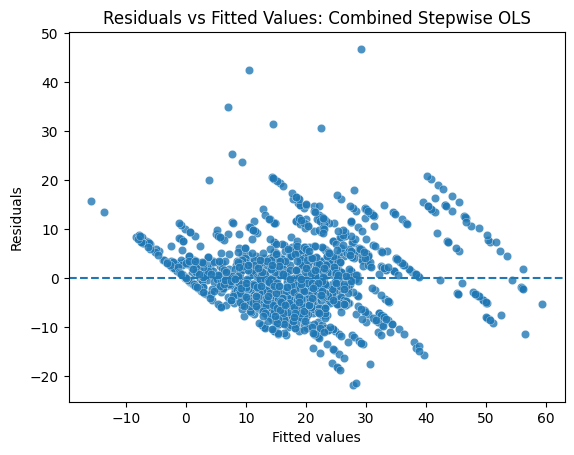

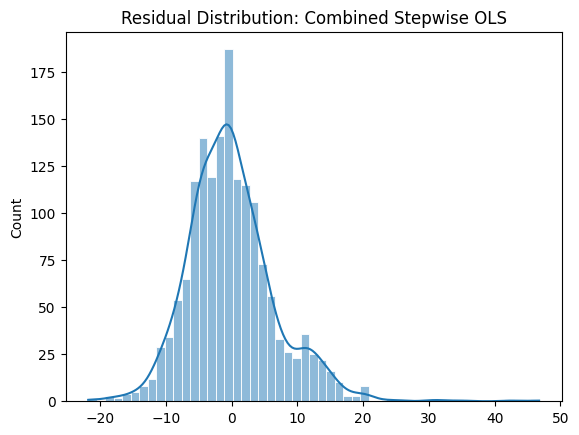

JB: SignificanceResult(statistic=np.float64(1059.4946745730952), pvalue=np.float64(8.58330635282942e-231))
BP Test: (np.float64(154.54931340873375), np.float64(5.387768695065582e-16), np.float64(4.777349525916038), np.float64(5.40001553159806e-18))


In [33]:
# Residual diagnostics for the selected combined stepwise model
residuals = analysis_model.resid
fitted_values = analysis_model.fittedvalues

print('Residual diagnostics for:', analysis_model_name)

# Linearity
sns.scatterplot(x=fitted_values, y=residuals, edgecolor='white', linewidth=0.25, alpha=0.8)
plt.axhline(0, linestyle='--')
plt.xlabel('Fitted values')
plt.ylabel('Residuals')
plt.title(f'Residuals vs Fitted Values: {analysis_model_name}')
plt.show()

# Normality
sns.histplot(residuals, kde=True, edgecolor='white')
plt.title(f'Residual Distribution: {analysis_model_name}')
plt.show()

# Jarque-Bera
print('JB:', jarque_bera(residuals))

# Heteroskedasticity
print('BP Test:', het_breuschpagan(residuals, X_train_analysis))


## 10. Examine Variable Distributions

/tmp/ipykernel_30670/575603712.py:7: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  'skewness': [skew(df[c].dropna()) for c in numeric_cols],
/tmp/ipykernel_30670/575603712.py:8: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  'kurtosis': [kurtosis(df[c].dropna()) for c in numeric_cols],


                                         feature         mean        std  \
18                                shrug_st_share     0.035494   0.009499   
27                       shrug_salary_priv_share     0.010988   0.001910   
29                     shrug_veh_two_three_share     0.037894   0.013010   
17                                shrug_sc_share     0.001087   0.004703   
25                        shrug_salary_any_share     0.200283   0.008672   
..                                           ...          ...        ...   
7                               train_type_count     5.332002   2.986334   
68             distance_to_nearest_major_hub_log     5.156894   0.679422   
47  sector_primary_sector_current_shares_percent    25.947589  10.615460   
59                            sector_sector_year  2010.000000   1.781804   
36                                          Year  2024.000000   0.000000   

     skewness    kurtosis  
18  26.294759  756.303120  
27  24.188292  669.901425  
29 

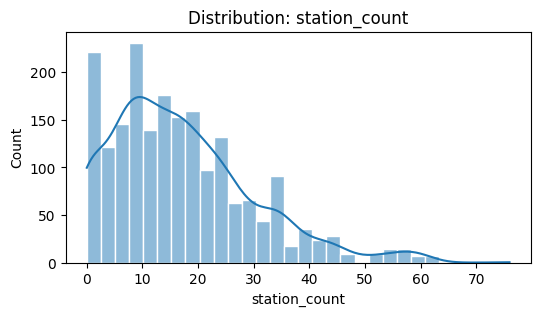

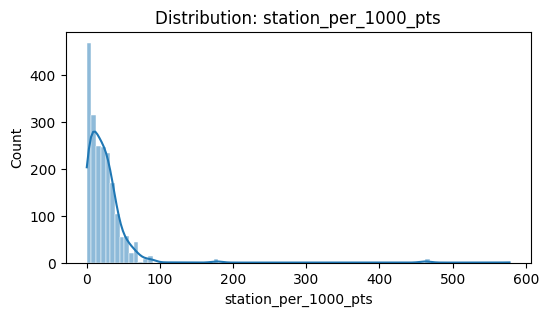

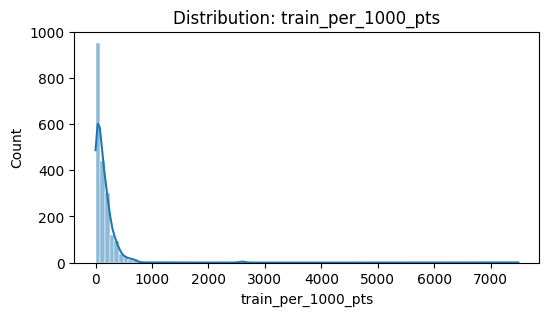

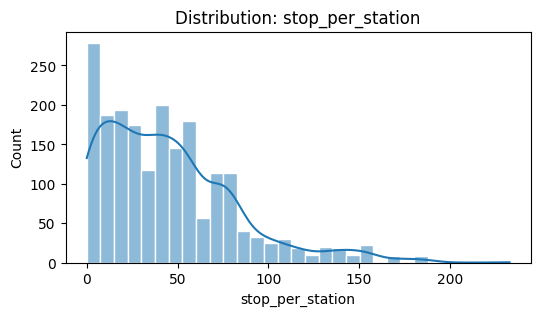

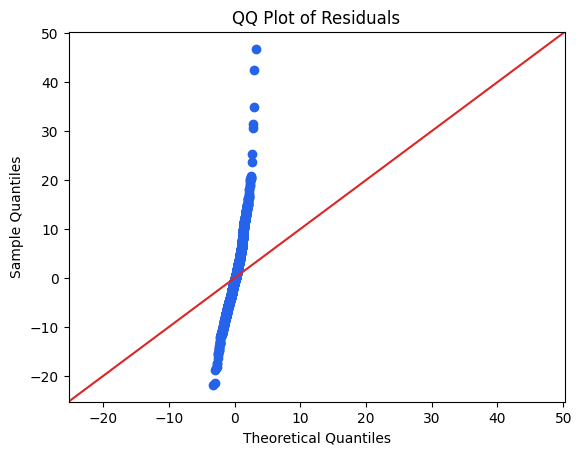

Residual skewness: 0.9649826035879104
Residual kurtosis: 3.485371385296591
Shapiro-Wilk: ShapiroResult(statistic=np.float64(0.9547579286491046), pvalue=np.float64(7.301100300261219e-22))


In [37]:
# Distribution summary for numeric variables used in modeling
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
dist_summary = pd.DataFrame({
    'feature': numeric_cols,
    'mean': [df[c].mean() for c in numeric_cols],
    'std': [df[c].std() for c in numeric_cols],
    'skewness': [skew(df[c].dropna()) for c in numeric_cols],
    'kurtosis': [kurtosis(df[c].dropna()) for c in numeric_cols],
})
print(dist_summary.sort_values('skewness', key=np.abs, ascending=False))

# Histograms for target and key rail accessibility components
plot_cols = [
    target_col,
    'station_per_1000_pts',
    'train_per_1000_pts',
    'stop_per_station',
]
plot_cols = [c for c in plot_cols if c in df.columns]
for col in plot_cols:
    plt.figure(figsize=(6, 3))
    sns.histplot(df[col].dropna(), kde=True, edgecolor='white')
    plt.title(f'Distribution: {col}')
    plt.show()

# QQ plot + normality checks on residuals
sm.qqplot(residuals, line='45')
plt.gca().get_lines()[0].set_markerfacecolor(cold_color)
plt.gca().get_lines()[0].set_markeredgecolor(cold_color)
plt.gca().get_lines()[1].set_color(hot_color)
plt.title('QQ Plot of Residuals')
plt.show()

print('Residual skewness:', skew(residuals))
print('Residual kurtosis:', kurtosis(residuals))
if len(residuals) >= 3 and len(residuals) <= 5000:
    print('Shapiro-Wilk:', shapiro(residuals))


## 11. Test Overall and Incremental Model Fit


In [ ]:
if np.isfinite(analysis_model.fvalue) and np.isfinite(analysis_model.f_pvalue):
    print(f'{analysis_model_name} F-statistic:', analysis_model.fvalue)
    print(f'{analysis_model_name} p-value:', analysis_model.f_pvalue)
else:
    print(f'{analysis_model_name} F-test is undefined (likely due to small sample and/or rank deficiency).')

baseline_candidates = [
    'shrug_tot_p', 'shrug_sc_share', 'shrug_st_share',
    'Year', 'Unemployment Rate (%)', 'sector_per_capita_current_prices_1000_in_rs',
    'distance_to_nearest_major_hub_km', 'distance_to_nearest_major_hub_log'
]
baseline_vars = [c for c in baseline_candidates if c in analysis_predictors]

if len(baseline_vars) > 0:
    X_train_reduced = sm.add_constant(X_train[baseline_vars], has_constant='add')
    reduced_model = sm.OLS(y_train, X_train_reduced).fit()

    print('Partial F-test (Reduced baseline vs Combined Stepwise):')
    try:
        compare = anova_lm(reduced_model, analysis_model)
        print(compare)
    except Exception as e:
        print(f'Could not compute ANOVA partial F-test: {e}')

    extra_vars = [c for c in analysis_predictors if c not in baseline_vars]
    if extra_vars:
        hypothesis = ' = 0, '.join(extra_vars) + ' = 0'
        print('Joint F-test for selected non-baseline vars:', hypothesis)
        try:
            print(analysis_model.f_test(hypothesis))
        except Exception as e:
            print(f'Could not compute joint F-test (often rank/small-sample issue): {e}')
else:
    print('No baseline variables from the compact list were selected into the combined stepwise model.')


Combined Stepwise OLS F-statistic: 125.59868300070879
Combined Stepwise OLS p-value: 0.0
Partial F-test (Reduced baseline vs Combined Stepwise):
   df_resid            ssr  df_diff        ss_diff           F  Pr(>F)
0    1597.0  258447.832800      0.0            NaN         NaN     NaN
1    1566.0   72817.017343     31.0  185630.815457  128.779653     0.0
Joint F-test for selected non-baseline vars: rail_density_log = 0, sector_primary_sector_constant_prices_in_millions_rs = 0, sector_primary_sector_current_shares_percent = 0, Youth Unemployment Rate (%) = 0, access_potential_log = 0, stop_per_station = 0, sector_total_constant_prices_in_millions_rs = 0, sector_econ_available = 0, ICT Sector Employment (%) = 0, SME Employment (%) = 0, Tourism Sector Employment (%) = 0, sector_tertiary_sector_current_prices_millions_in_rs = 0, rail_density = 0, train_per_1000_pts = 0, Patents per 100,000 Inhabitants = 0, R&D Expenditure (% of GDP) = 0, sector_sector_year = 0, sector_primary_sector_curre

/home/aps834009/HW/.venv/lib/python3.11/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 34, but rank is 27
  warnings.warn('covariance of constraints does not have full '


: 

## 12. Check Multicollinearity with VIF

VIF is now calculated on the selected combined stepwise model design matrix. This gives a cleaner multicollinearity check for the predictors being interpreted, instead of the much larger original predictor set.


In [39]:
vif_data = pd.DataFrame()
vif_data['feature'] = X_train_analysis.columns
vif_data['VIF'] = [
    variance_inflation_factor(X_train_analysis.values, i)
    for i in range(X_train_analysis.shape[1])
]
print(vif_data.sort_values('VIF', ascending=False))


/home/aps834009/HW/.venv/lib/python3.11/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
/home/aps834009/HW/.venv/lib/python3.11/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


                                              feature           VIF
28                               station_per_1000_pts           inf
36                      sector_year_label_2011 (2004)           inf
37                      sector_year_label_2012 (2004)           inf
35                      sector_year_label_2010 (2004)           inf
20                                 sector_sector_year           inf
16                                       rail_density           inf
9                               sector_econ_available           inf
32                                     major_hub_flag           inf
33                      sector_year_label_2008 (2004)           inf
34                      sector_year_label_2009 (2004)           inf
26                                     econ_available           inf
38                      sector_year_label_2013 (2004)           inf
7         sector_total_constant_prices_in_millions_rs  8.717094e+10
31  sector_tertiary_sector_constant_prices_milli

## 12. Interpret the VIF Results

This cell translates the VIF table into practical modeling guidance. If several predictors are highly collinear, coefficient signs and magnitudes should be interpreted carefully.


In [43]:
vif_sorted = vif_data.sort_values('VIF', ascending=False).copy()

high_vif = vif_sorted[(vif_sorted['feature'] != 'const') & (vif_sorted['VIF'] > 10)]
moderate_vif = vif_sorted[(vif_sorted['feature'] != 'const') & (vif_sorted['VIF'] > 5) & (vif_sorted['VIF'] <= 10)]
print(moderate_vif)

                              feature       VIF
17                 train_per_1000_pts  7.008657
12   distance_to_nearest_major_hub_km  5.648240
10  distance_to_nearest_major_hub_log  5.442697


## 13. Validate the Selected Stepwise Model

Holdout and cross-validation metrics now evaluate the combined stepwise model. This is the main check before using its predictions to create access gaps and rail-desert rankings.


In [51]:
pred = analysis_model.predict(X_test_analysis)

rmse = float(np.sqrt(mean_squared_error(y_test, pred)))
mae = float(mean_absolute_error(y_test, pred))
r2 = float(r2_score(y_test, pred))

denom = np.where(np.abs(y_test.values) < 1e-8, np.nan, np.abs(y_test.values))
mape = float(np.nanmean(np.abs((y_test.values - pred.values) / denom)) * 100)

print('Target:', target_col)
print(f'Holdout ({analysis_model_name})')
print('R2:', r2)
print('RMSE:', rmse)
print('MAE:', mae)
print('MAPE (%):', mape)

baseline_pred = np.repeat(y_train.mean(), len(y_test))
baseline_rmse = float(np.sqrt(mean_squared_error(y_test, baseline_pred)))
print('Baseline RMSE (predict train mean):', baseline_rmse)
print('RMSE Improvement vs Baseline (%):', 100 * (baseline_rmse - rmse) / baseline_rmse)

X_cv = X_analysis.copy()
y_cv = y.copy()

kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_rmse = []
cv_r2 = []

for train_idx, test_idx in kf.split(X_cv):
    X_tr = X_cv.iloc[train_idx]
    X_te = X_cv.iloc[test_idx]
    y_tr = y_cv.iloc[train_idx]
    y_te = y_cv.iloc[test_idx]

    m = sm.OLS(y_tr, X_tr).fit()
    p = m.predict(X_te)

    cv_rmse.append(np.sqrt(mean_squared_error(y_te, p)))
    cv_r2.append(r2_score(y_te, p))

print()
print(f'5-Fold CV ({analysis_model_name})')
print('CV RMSE mean +/- std:', float(np.mean(cv_rmse)), '+/-', float(np.std(cv_rmse)))
print('CV R2 mean +/- std:', float(np.mean(cv_r2)), '+/-', float(np.std(cv_r2)))



Target: station_count
Holdout (Combined Stepwise OLS)
R2: 0.7269892449522264
RMSE: 6.141604421223029
MAE: 4.7221264585601395
MAPE (%): 44.90659841161967
Baseline RMSE (predict train mean): 11.778286868085251
RMSE Improvement vs Baseline (%): 47.85655596600828

5-Fold CV (Combined Stepwise OLS)
CV RMSE mean +/- std: 6.892134330327053 +/- 0.45668304855171854
CV R2 mean +/- std: 0.7125649290587798 +/- 0.02412021897311035


## 13A. Compare Candidate Model


In [52]:
model_rows = []

pred_original = model.predict(X_test)
model_rows.append({
    'model_name': 'Original Full OLS',
    'r2': float(r2_score(y_test, pred_original)),
    'rmse': float(np.sqrt(mean_squared_error(y_test, pred_original))),
    'holdout_mae': float(mean_absolute_error(y_test, pred_original)),
})

pred_stepwise = analysis_model.predict(X_test_analysis)
model_rows.append({
    'model_name': analysis_model_name,
    'r2': float(r2_score(y_test, pred_stepwise)),
    'rmse': float(np.sqrt(mean_squared_error(y_test, pred_stepwise))),
    'mae': float(mean_absolute_error(y_test, pred_stepwise)),
})

if 'model_reduced_vif' in globals() and 'X_test_reduced_vif' in globals():
    pred_reduced = model_reduced_vif.predict(X_test_reduced_vif)
    model_rows.append({
        'model_name': 'Reduced-VIF Selected OLS',
        'r2': float(r2_score(y_test, pred_reduced)),
        'rmse': float(np.sqrt(mean_squared_error(y_test, pred_reduced))),
        'mae': float(mean_absolute_error(y_test, pred_reduced)),
    })

comparison_df = pd.DataFrame(model_rows)
comparison_df = comparison_df.sort_values(['rmse', 'mae', 'r2'], ascending=[True, True, False]).reset_index(drop=True)
comparison_df['rank'] = np.arange(1, len(comparison_df) + 1)
comparison_df = comparison_df[['rank', 'model_name', 'r2', 'rmse', 'mae']]
print(comparison_df)

best_model_name = comparison_df.iloc[0]['model_name']
print('lowest RMSE):', best_model_name)


   rank                model_name        r2      rmse       mae
0     1     Combined Stepwise OLS  0.726989  6.141604  4.722126
1     2         Original Full OLS  0.724350  6.171214       NaN
2     3  Reduced-VIF Selected OLS  0.720014  6.219570  4.692757
lowest RMSE): Combined Stepwise OLS


## 15. Final Railway Desert


In [49]:
df['predicted_target'] = analysis_model.predict(X_analysis)
df['access_gap'] = df[target_col] - df['predicted_target']
df['rail_desert_flag'] = df['access_gap'] < df['access_gap'].quantile(0.10)

# Coefficient based weighted Rail Accessibility Score (RAS)
coefficient_weights = analysis_model.params.drop(labels='const', errors='ignore')
coefficient_predictors = [c for c in coefficient_weights.index if c in X_analysis.columns]
coefficient_weights = coefficient_weights.loc[coefficient_predictors]

coefficient_contributions = X_analysis[coefficient_predictors].mul(coefficient_weights, axis=1)
df['coefficient_weighted_access_score'] = coefficient_contributions.sum(axis=1)

# Normalization
score_min = df['coefficient_weighted_access_score'].min()
score_max = df['coefficient_weighted_access_score'].max()
if np.isclose(score_max, score_min):
    df['rail_accessibility_score'] = 0.5
else:
    df['rail_accessibility_score'] = (
        (df['coefficient_weighted_access_score'] - score_min) /
        (score_max - score_min)
    )
df['rail_accessibility_score'] = df['rail_accessibility_score'].clip(0, 1)

print('Rail Accessibility Score weighting: selected-model coefficients')
print()
print('Coefficient weights used in the index:')
display(coefficient_weights.to_frame('coefficient_weight'))

df[[
    'district', 'state', 'rail_accessibility_score',
    'coefficient_weighted_access_score', 'predicted_target',
    'access_gap', 'rail_desert_flag'
]].sort_values(['rail_accessibility_score', 'access_gap']).head(25)


Rail Accessibility Score weighting: selected-model coefficients

Coefficient weights used in the index:


,coefficient_weight
rail_density_log,1.028337e+01
sector_primary_sector_constant_prices_in_millions_rs,-5.192236e-02
sector_primary_sector_current_shares_percent,5.614425e-02
Youth Unemployment Rate (%),-6.741481e+00
access_potential_log,-5.484530e+00
stop_per_station,9.022050e-02
sector_total_constant_prices_in_millions_rs,5.261330e-02
sector_per_capita_current_prices_1000_in_rs,-8.935678e-02
sector_econ_available,-1.949987e+02
distance_to_nearest_major_hub_log,-2.454734e+00


,district,state,rail_accessibility_score,coefficient_weighted_access_score,predicted_target,access_gap,rail_desert_flag
1122,lahul and spiti,himachal pradesh,0.000000,-15.297832,-15.811688,15.811688,False
1123,lahul and spiti,himachal pradesh,0.029717,-13.064935,-13.578792,13.578792,False
1121,lahul and spiti,himachal pradesh,0.079172,-9.348836,-9.862692,9.862692,False
1389,panna,madhya pradesh,0.094369,-8.206935,-8.720791,9.720791,False
1120,lahul and spiti,himachal pradesh,0.100247,-7.765294,-8.279150,8.279150,False
1117,lahul and spiti,himachal pradesh,0.102212,-7.617607,-8.131464,8.131464,False
1021,kinnaur,himachal pradesh,0.104536,-7.443028,-7.956884,7.956884,False
1408,pathanamthitta,kerala,0.106918,-7.264005,-7.777862,8.777862,False
1394,panna,madhya pradesh,0.108126,-7.173235,-7.687092,8.687092,False
1390,panna,madhya pradesh,0.108577,-7.139405,-7.653262,8.653262,False


## 16. Map the District Results


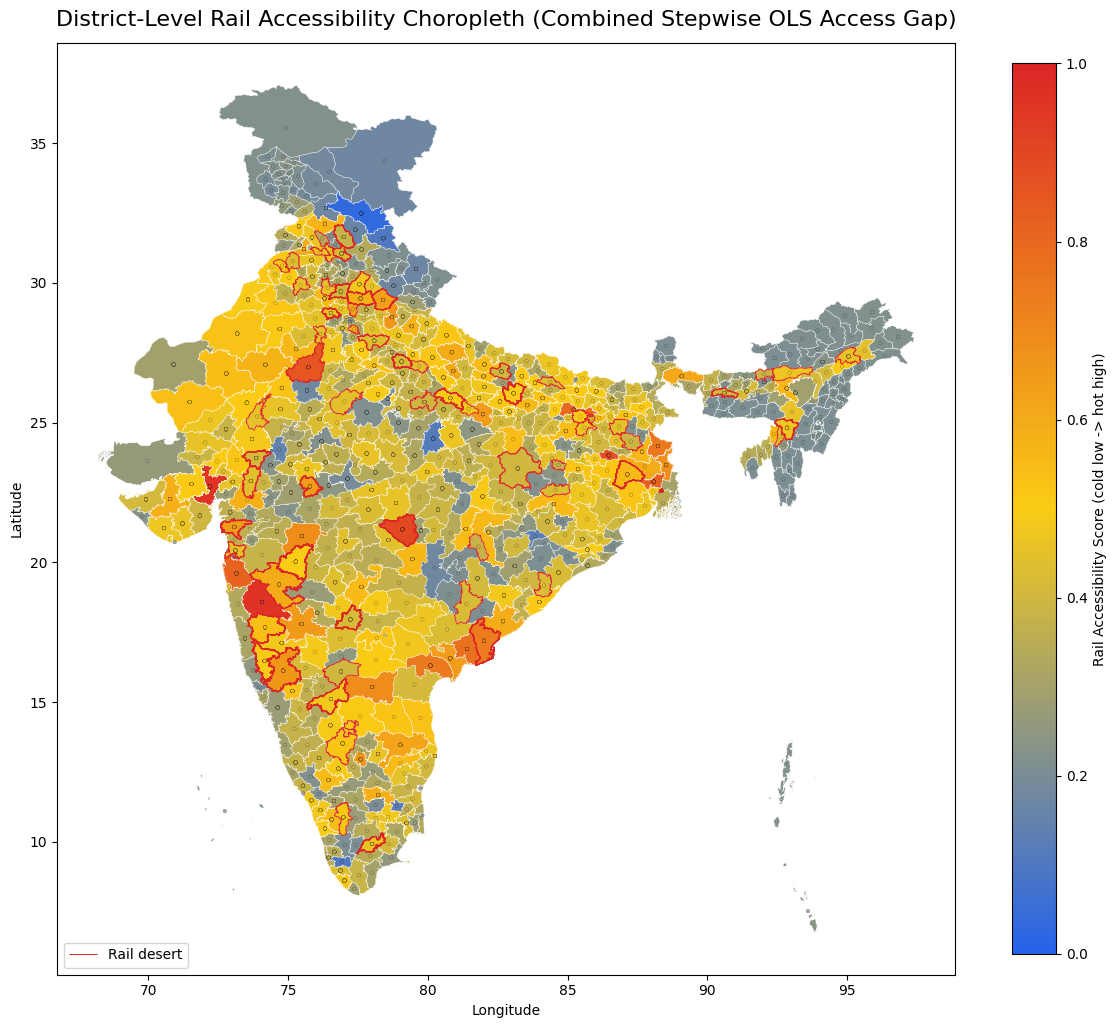

In [50]:
# District choropleth map with longitude/latitude centroid overlay
map_cols = [
    'district_key', 'district', 'state',
    'rail_accessibility_score', 'access_gap', 'rail_desert_flag',
    'centroid_lat', 'centroid_lon'
]
map_cols = [c for c in map_cols if c in df.columns]

map_gdf = districts[['district_key', 'geometry']].merge(
    df[map_cols],
    on='district_key',
    how='inner'
).dropna(subset=['rail_accessibility_score', 'centroid_lat', 'centroid_lon'])

if map_gdf.crs is None:
    map_gdf = map_gdf.set_crs(epsg=4326, allow_override=True)
else:
    map_gdf = map_gdf.to_crs(epsg=4326)

fig, ax = plt.subplots(figsize=(12, 14))

map_gdf.plot(
    column='rail_accessibility_score',
    cmap=cold_warm_hot_cmap,
    linewidth=0.25,
    edgecolor='white',
    legend=True,
    legend_kwds={
        'label': 'Rail Accessibility Score (cold low -> hot high)',
        'shrink': 0.65
    },
    missing_kwds={
        'color': 'lightgrey',
        'edgecolor': 'white',
        'label': 'Missing data'
    },
    ax=ax
)

centroid_plot = map_gdf.dropna(subset=['centroid_lon', 'centroid_lat'])
ax.scatter(
    centroid_plot['centroid_lon'],
    centroid_plot['centroid_lat'],
    c=centroid_plot['rail_accessibility_score'],
    cmap=cold_warm_hot_cmap,
    s=7,
    linewidths=0.15,
    edgecolors='black',
    alpha=0.75
)

if 'rail_desert_flag' in map_gdf.columns:
    desert_gdf = map_gdf[map_gdf['rail_desert_flag'] == True]
    if not desert_gdf.empty:
        desert_gdf.boundary.plot(ax=ax, color=hot_color, linewidth=0.7, label='Rail desert')
        ax.legend(loc='lower left', frameon=True)

ax.set_title(f'District-Level Rail Accessibility Choropleth ({analysis_model_name} Access Gap)', fontsize=16, pad=12)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_aspect('equal')
ax.grid(False)
plt.tight_layout()
plt.show()
